# Imports

In [45]:
import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import dataset_prep, FISTA, labeled_log_reg, unlabeled_log_reg
importlib.reload(FISTA)
importlib.reload(labeled_log_reg)
importlib.reload(unlabeled_log_reg)
from labeled_log_reg import LabeledLogReg
from unlabeled_log_reg import UnlabeledLogReg
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

RANDOM_SEED = 42
np.random.seed(seed=RANDOM_SEED)

# Dataset loading

In [2]:
shopping_train, shopping_val, shopping_test = dataset_prep.get_dataset("shopping")

Percentage of labels removed: 14.78%
Percentage of labels removed: 13.13%
Percentage of labels removed: 13.51%
Percentage of labels removed: 10.18%


In [3]:
smartphone_train, smartphone_val, smartphone_test = dataset_prep.get_dataset("smartphone")

Percentage of labels removed: 15.44%
Percentage of labels removed: 13.76%
Percentage of labels removed: 13.80%
Percentage of labels removed: 16.20%


In [4]:
software_train, software_val, software_test = dataset_prep.get_dataset("software")

Percentage of labels removed: 13.20%
Percentage of labels removed: 12.60%
Percentage of labels removed: 12.00%
Percentage of labels removed: 10.80%


In [5]:
wine_train, wine_val, wine_test = dataset_prep.get_dataset("wine")

Percentage of labels removed: 12.96%
Percentage of labels removed: 12.43%
Percentage of labels removed: 13.49%
Percentage of labels removed: 12.78%


In [6]:
len(np.ones(wine_test.drop(columns=["quality"]).shape[0]))

286

In [7]:
wine_train, wine_val, wine_test = dataset_prep.get_dataset("wine")

Percentage of labels removed: 12.96%
Percentage of labels removed: 12.43%
Percentage of labels removed: 13.49%
Percentage of labels removed: 12.78%


# Labeled logistic regression
This section runs the custom labeled logistic regression implementation from `labeled_log_reg.py` and compares the FISTA solution with the sklearn baseline. The validation and test feature matrices are aligned to the training columns before fitting so the shapes stay consistent.

### FISTA implementation
Fit the custom FISTA-based logistic lasso model on the training split, choose `lambda` on the validation split, and inspect the evaluation curve and coefficient path. The lambda grid is widened here so the coefficient paths are easier to see.

In [10]:
# target_col = "shopping_preference"
# X_train = shopping_train.drop(columns=[target_col])
# y_train = shopping_train[target_col]
# X_valid = shopping_val.reindex(columns=X_train.columns, fill_value=0)
# y_valid = shopping_val[target_col]

# fista_model = LabeledLogReg(implementation="fista", lambda_grid=[10**i for i in range(-5, 5)])
# fista_model.fit(X_train, y_train)
# fista_result = fista_model.validate(X_valid, y_valid, measure="f_measure")

# print("FISTA best lambda:", fista_result["best_lambda"] )
# print("FISTA validation score:", fista_result["best_score"] )
# fista_pred_proba = fista_model.predict_proba(X_valid)
# fista_pred_proba[:5]

In [11]:
# fista_model.plot("f_measure")
# fista_model.plot_coefficients(feature_names=X_train.columns.tolist())

### sklearn baseline
Run the same train/validation split with the sklearn implementation to compare the selected `lambda` and validation score against the custom FISTA solver.

In [ ]:
# TODO: replace this with sklearns logreg
# sklearn_model = LabeledLogReg(implementation="sklearn", n_lambdas=20, max_iter=2000)
# sklearn_model.fit(X_train, y_train)
# sklearn_result = sklearn_model.validate(X_valid, y_valid, measure="f_measure")

# print("sklearn best lambda:", sklearn_result["best_lambda"])
# print("sklearn validation score:", sklearn_result["best_score"])
# sklearn_pred_proba = sklearn_model.predict_proba(X_valid)
# sklearn_pred_proba[:5]



# Experiments

## FISTA vs `sklearn`'s `LogisticRegression`

Firstly, we will take a look on the parameters predicted by our and `sklearn`'s implementation of logistic regression. Moreover, we will see if the optimal lambda parameter is the same in both implementations.

To train these models, we will use fully labeled data (no missingness).

### Profile plots

We want to see how parameter values change with lambda.

/home/janek/ds/2/aml/AML_project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/janek/ds/2/aml/AML_project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/janek/ds/2/aml/AML_project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/janek/ds/2/aml/AML_project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/janek/ds/2/aml/AML_project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

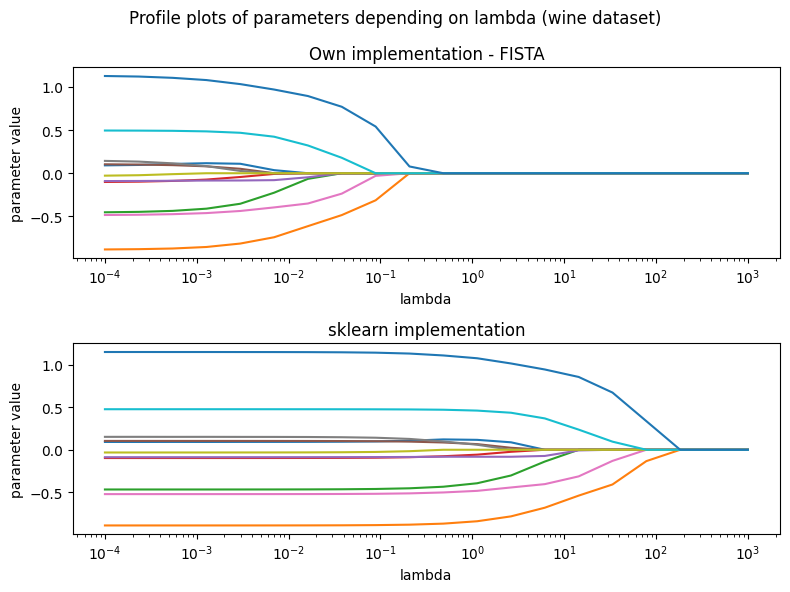

In [87]:
X_train = wine_train.iloc[:, :-5]
y_train = wine_train.iloc[:, -5]

lambdas = [10**i for i in np.linspace(-4, 3, 20)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

fista_model = LabeledLogReg(lambda_grid=lambdas)
fista_model.fit(X_train, y_train)
coefficients_fista = [model.coef for model in fista_model.models_]

sklearn_models = []
coefficients_sklearn = []
for l in lambdas:
    sklearn_model = LogisticRegression(l1_ratio=1, C=1/l, solver="saga")
    sklearn_model.fit(X_train, y_train)
    sklearn_models.append(sklearn_model)
    coefficients_sklearn.append(sklearn_model.coef_.ravel())

for i in range(X_train.shape[1]):
    coef_fista = [x[i] for x in coefficients_fista]
    ax1.plot(lambdas, coef_fista)
    coef_sklearn = [x[i] for x in coefficients_sklearn]
    ax2.plot(lambdas, coef_sklearn)

fig.suptitle("Profile plots of parameters depending on lambda (wine dataset)")
ax1.set_xscale("log")
ax1.set_xlabel("lambda")
ax1.set_ylabel("parameter value")
ax1.set_title("Own implementation - FISTA")
ax2.set_xscale("log")
ax2.set_xlabel("lambda")
ax2.set_ylabel("parameter value")
ax2.set_title("sklearn implementation")
fig.tight_layout()

### Performance comparison

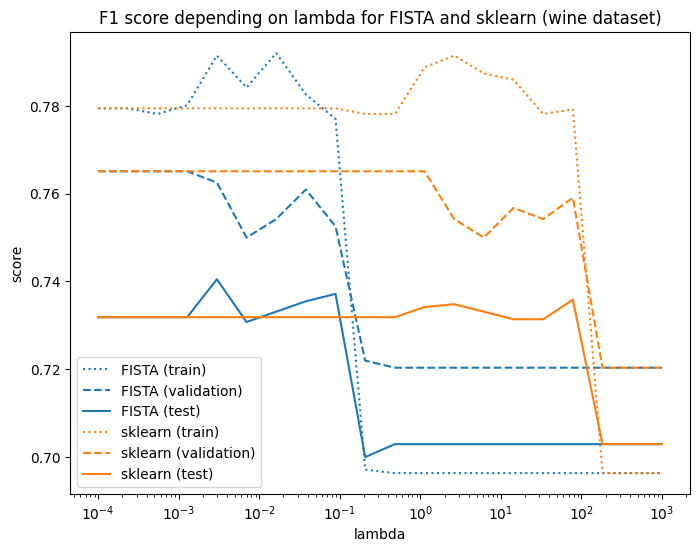

In [88]:
X_val = wine_val.iloc[:, :-1]
y_val = wine_val.iloc[:, -1]
X_test = wine_test.iloc[:, :-1]
y_test = wine_test.iloc[:, -1]

fista_f1_train = fista_model.validate(X_train, y_train, measure="f_measure")["scores"]
fista_f1_val = fista_model.validate(X_val, y_val, measure="f_measure")["scores"]
fista_f1_test = fista_model.validate(X_test, y_test, measure="f_measure")["scores"]

sklearn_f1_train = [f1_score(y_train, model.predict(X_train)) for model in sklearn_models]
sklearn_f1_val = [f1_score(y_val, model.predict(X_val)) for model in sklearn_models]
sklearn_f1_test = [f1_score(y_test, model.predict(X_test)) for model in sklearn_models]

plt.figure(figsize=(8, 6))

plt.plot(lambdas, fista_f1_train, label="FISTA (train)", c="tab:blue", linestyle="dotted")
plt.plot(lambdas, fista_f1_val, label="FISTA (validation)", c="tab:blue", linestyle="dashed")
plt.plot(lambdas, fista_f1_test, label="FISTA (test)", c="tab:blue", linestyle="solid")

plt.plot(lambdas, sklearn_f1_train, label="sklearn (train)", c="tab:orange", linestyle="dotted")
plt.plot(lambdas, sklearn_f1_val, label="sklearn (validation)", c="tab:orange", linestyle="dashed")
plt.plot(lambdas, sklearn_f1_test, label="sklearn (test)", c="tab:orange", linestyle="solid")

plt.xscale("log")
plt.xlabel("lambda")
# plt.ylim(ymin=0.65, ymax=0.8)
plt.ylabel("score")
plt.title("F1 score depending on lambda for FISTA and sklearn (wine dataset)")
plt.legend()

## Missing labels - MCAR

### Constant missingness probability

In [42]:
X_train = shopping_train.iloc[:, :-5]
y_train_full = shopping_train.iloc[:, -5]
y_train = shopping_train.iloc[:, -4]
X_val = shopping_val.iloc[:, :-1]
y_val = shopping_val.iloc[:, -1]
X_test = shopping_test.iloc[:, :-1]
y_test = shopping_test.iloc[:, -1]

In [46]:
labeler = UnlabeledLogReg()

fista_naive = LabeledLogReg()
labeler.fit(fista_naive, X_train, y_train, method="naive")
val_naive = fista_naive.validate(X_val, y_val, measure="f1")
test_naive = fista_naive.validate(X_test, y_test, measure="f1")

fista_knn = LabeledLogReg()
labeler.fit(fista_knn, X_train, y_train, method="knn")
val_knn = fista_knn.validate(X_val, y_val, measure="f1")
test_knn = fista_knn.validate(X_test, y_test, measure="f1")

fista_lda = LabeledLogReg()
labeler.fit(fista_lda, X_train, y_train, method="lda")
val_lda = fista_lda.validate(X_val, y_val, measure="f1")
test_lda = fista_lda.validate(X_test, y_test, measure="f1")

fista_oracle = LabeledLogReg()
labeler.fit(fista_oracle, X_train, y_train_full, method="oracle")
val_oracle = fista_oracle.validate(X_val, y_val, measure="f1")
test_oracle = fista_oracle.validate(X_test, y_test, measure="f1")

In [47]:
val_naive

{'measure': 'f1',
 'lambdas': array([1.92125934e-01, 1.51404128e-01, 1.19313460e-01, 9.40245285e-02,
        7.40956801e-02, 5.83908252e-02, 4.60146727e-02, 3.62616917e-02,
        2.85758913e-02, 2.25191249e-02, 1.77461126e-02, 1.39847581e-02,
        1.10206366e-02, 8.68477169e-03, 6.84400203e-03, 5.39339035e-03,
        4.25024121e-03, 3.34938678e-03, 2.63947180e-03, 2.08002594e-03,
        1.63915671e-03, 1.29173135e-03, 1.01794408e-03, 8.02187051e-04,
        6.32160523e-04, 4.98171749e-04, 3.92582395e-04, 3.09373096e-04,
        2.43800318e-04, 1.92125934e-04]),
 'scores': array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.21634615, 0.55938697, 0.66666667, 0.7299509 , 0.79262673,
        0.84319527, 0.88057554, 0.91188811, 0.92797784, 0.93844049,
        0.94952251, 0.95380435, 0.9660787 , 0.9717362 , 0.97442799,
        0.97849462, 0.98123324, 0.97860963, 0.98128342, 0.97866667,
        0.97736352, 0.97866667, 0.97730307, 0.976     , 0.97463284]),
 'bes

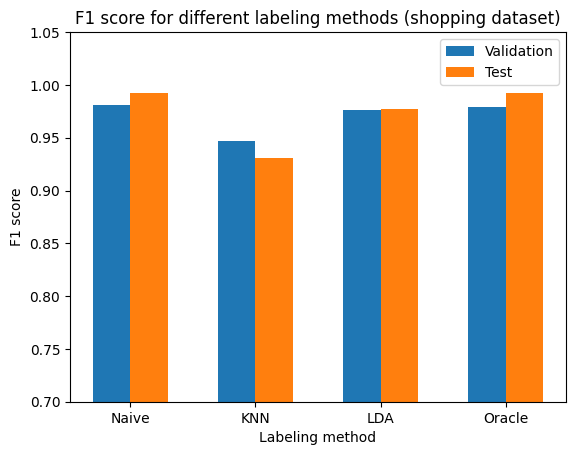

In [57]:
bar_width = 0.3
plt.bar(np.arange(4) - bar_width/2, [val_naive["best_score"], val_knn["best_score"], val_lda["best_score"], val_oracle["best_score"]], bar_width, label="Validation")
plt.bar(np.arange(4) + bar_width/2, [test_naive["best_score"], test_knn["best_score"], test_lda["best_score"], test_oracle["best_score"]], bar_width, label="Test")
plt.xticks(np.arange(4), ["Naive", "KNN", "LDA", "Oracle"])
plt.xlabel("Labeling method")
plt.ylim(ymin=0.7, ymax=1.05)
plt.ylabel("F1 score")
plt.title("F1 score for different labeling methods (shopping dataset)")
plt.legend(loc="upper right")

In [ ]:
# Numbers of pairs of bars you want
N = 3

# Data on X-axis

# Specify the values of blue bars (height)
blue_bar = (23, 25, 17)
# Specify the values of orange bars (height)
orange_bar = (19, 18, 14)

# Position of bars on x-axis
ind = np.arange(N)

# Figure size
plt.figure(figsize=(10,5))

# Width of a bar 
width = 0.3       

# Plotting
plt.bar(ind, blue_bar , width, label='Blue bar label')
plt.bar(ind + width, orange_bar, width, label='Orange bar label')

plt.xlabel('Here goes x-axis label')
plt.ylabel('Here goes y-axis label')
plt.title('Here goes title of the plot')

# xticks()
# First argument - A list of positions at which ticks should be placed
# Second argument -  A list of labels to place at the given locations
plt.xticks(ind + width / 2, ('Xtick1', 'Xtick3', 'Xtick3'))

# Finding the best position for legends and putting it
plt.legend(loc='best')
plt.show()
